# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

[Fornecemos alguns comentários para guiar sua linha de raciocínio enquanto você trabalha neste projeto. Entretanto, certifique-se de remover todos os comentários entre colchetes antes de enviar o projeto.]

[Antes de começar a análise dos dados, explique com suas próprias palavras o propósito do projeto e as ações que planeja realizar.]

[Tenha em mente que estudar, modificar e analisar dados é um processo iterativo. É normal retornar a etapas anteriores e corrigir/expandir algo para permitir as próximas etapas.]

## Inicialização

In [ ]:
# Carregando todas as bibliotecas
import pandas as pd 
from matplotlib import pyplot as plt 
import numpy as np
import seaborn as sns 
from scipy import stats as st 
from math import factorial
import math as m 

## Carregue os dados

In [ ]:
# Carregue os arquivos de dados em diferentes DataFrames

users = pd.read_csv('/datasets/megaline_users.csv')
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')

## Prepare os dados

## 

Fazendo uma análise visual dos dados a serem explorados.
Abrindo os arquivos das tabelas e analisando os dados, pude notar alguns pontos para nós aprofundarmos um pouco melhor:                                      Users: Grande parte dos clientes ultilizam o plano Surf, vamos olhar melhor os dados para entender o nível de consumo dos clientes.
    Calls: Alguns clientes tem duração de chamada de voz 0.0, o que não pode acontecer neste caso, visto que mesmo que a chamada tenha durado segundos, o tempo de duração da chamada teria que ser arredondado para 1.0. 
    Messages: Existe um grande volume de envio de mensagem por parte dos clientes.
    Internet: Também existe alguns valores de gasto de dados 0.0, vamos tratar esses valores.    

## Planos

In [356]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [357]:
#Imprima uma amostra de dados dos planos
plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Podemos notar que a coluna usd_per_gb e a coluna usd_monthly_pay não estão com os dtypes corretos, o que deveria ser um 'float' está como 'int'. Podemos chamar a função to_numeric para verificar que não teremos problemas ao converter as colunas, caso haja algum valor que não possa ser alterado (errors='coerce') fará com que os valores retornem 'Nan', depois disso podemos então usar a função .astype() para trocar os dtypes das colunas usd_per_gb e usd_monthly_pay .

## Corrija os dados

In [358]:
#Verificando se podemos trocar os dtypes das colunas sem prejudicar os dados.

plans['usd_per_gb'] = pd.to_numeric(plans['usd_per_gb'],errors='coerce')

plans['usd_monthly_pay'] = pd.to_numeric(plans['usd_monthly_pay'],errors='coerce')

In [359]:
#Convertendo as colunas 'usd_per_gb' e 'usd_monthly_pay' de int para float.
plans['usd_per_gb'] = plans['usd_per_gb'].astype('float')

plans['usd_monthly_pay'] = plans['usd_monthly_pay'].astype('float')

## Enriqueça os dados

Inclui uma a coluna gb_per_month_included na tabela plans, que passa o consumo mensal de mega para gb, visto que se trata de um número inteiro o que  facilita a análise. 

In [360]:
#Criando uma nova coluna para deixar o volume do pacote de dados em GB.

plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024

plans['gb_per_month_included'] = plans['gb_per_month_included'].astype('int')

## Usuários

In [361]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [362]:
# Imprima uma amostra de dados dos usuários
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


Podemos notar que as duas colunas que levam data (reg_date e churn_date) estão com o dtype 'object', quando deveriam ser 'datetime', com a função to_datetime podemos converter as colunas para datatime e (errors='coerce') para conferir se não danificamos nenhum dado aos trocar o dtype das colunas.

### Corrija os dados

.

In [363]:
#Convertendo as colunas de 'reg_date' e 'churn_date' de object para datetime.

users['reg_date'] = pd.to_datetime(users['reg_date'], format= '%Y-%m-%d',errors='coerce')

users['churn_date'] = pd.to_datetime(users['churn_date'], format= '%Y-%m-%d', errors='coerce')

### Enriqueça os dados

.

In [364]:
#Calculando quantos clientes usam o plano 'surf' e 'ultimate'.

users['plan'].value_counts()

surf        339
ultimate    161
Name: plan, dtype: int64

## Chamadas

In [365]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [366]:
# Imprima uma amostra de dados das chamadas
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


A coluna 'call_date' está como (object) e se trata de um datetime, vamos usar o método to_datetime() seguido de errors='coerce' para converter a coluna e verificar se não vamos danificar nenhum dado.

### Corrija os dados

.

In [367]:
#Convertendo a coluna de 'call_date' de object para datetime.

calls['call_date'] = pd.to_datetime(calls['call_date'], format= '%Y-%m-%d',errors='coerce')

### Enriqueça os dados

.

## Mensagens

In [368]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [369]:
# Imprima uma amostra dos dados das mensagens
messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


A coluna 'message_date' está como (object) e se trata de um datetime, vamos usar o método to_datetime() seguido de errors='coerce' para converter a coluna e verificar se não vamos danificar nenhum dado.

### Corrija os dados

.

In [370]:
#Convertendo a coluna de 'message_date' de object para datetime.

messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d', errors='coerce')

### Enriqueça os dados

.

## Internet

In [371]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [372]:
#  Imprima uma amostra de dados para o tráfego da internet
internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


A coluna 'session_date' está como (object) e se trata de um datetime, vamos usar o método to_datetime() seguido de errors='coerce' para converter a coluna e verificar se não vamos danificar nenhum dado. Também pude notar que temos valores como 0.0 na coluna 'mb_used', e optei por não converter o dtypes, não excluir as linhas e por não converter a coluna para gb, pelos seguintes motivos, não quero me desfazer da linhas que não tiveram gastos por ter sido uma entrada rápida ou algo do tipo e não vou criar outra coluna convertendo para gb porque vou perder dados de cobrança, visto que eles somam o consumo final e arredondam pra cima na hora de fechar a fatura.

### Corrija os dados

.

In [373]:
#Convertendo a coluna de 'session_date' de object para datetime.

internet['session_date'] = pd.to_datetime(internet['session_date'], format= '%Y-%m-%d', errors='coerce')

### Enriqueça os dados

.

In [374]:
#Observando quantas linhas o consumo de dados 0.
internet[internet['mb_used']== 0].shape[0]


13747




<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
</div>




## Estude as condições dos planos

Descrição dos planos: O plano 'Surf' custa 20 e pode usufruir de 15Gb,500minutos, e 50 mensagens, se exceder o plano terá um custo adicional de 10 por Gb, 0.03 por minuto e 0.03 por mensagem. Já o plano 'Ultimate' custa 70 e pode usufruir de 30Gb, 3000 minutos e 1000 mensagens, se exceder o plano terá um custo adicional de 7 por GB, 0.01 por minuto e $0.01 por mensagem. A cobrança da internet e feita por megabytes e arredondados para cima (1024 megabytes = 1Gb).

In [375]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você
plans


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20.0,10.0,0.03,0.03,surf,15
1,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,30


## Agregue os dados por usuário



In [376]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
#Criei uma nova coluna com os meses e ano do consumo, depois contei o número de chamadas cada usuário realizou.

calls['call_month'] = calls['call_date'].dt.to_period('M')

month_calls = calls.groupby(['user_id', 'call_month'])['id'].count()

In [377]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
#Como as cobranças são feitas por minutos, arredondei segundos para minutos na coluna para facilitar a análise.

calls_duration_month = calls.groupby(['user_id', 'call_month'])['duration'].sum().apply(m.ceil)

In [378]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
#Criei uma nova coluna com os meses e ano do consumo, depois contei o número de mensagens cada usuário enviou.

messages['messages_month'] = messages['message_date'].dt.to_period('M')

monthly_messages = messages.groupby(['user_id','messages_month'])['id'].count()

In [379]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
#Criei uma nova coluna com os meses e ano do consumo, depois contei o volume de tráfego de cada usuário ultilizou.

internet['month_internet'] = internet['session_date'].dt.to_period('M')

mb_monthly = internet.groupby(['user_id','month_internet'])['mb_used'].sum()


.

In [380]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
#Subistitui os valres Nan por 0, para não perder nenhum dado.

dados_combinados = pd.concat([month_calls , calls_duration_month , monthly_messages , mb_monthly ], axis=1, join='outer')
dados_combinados = dados_combinados.fillna(0)

In [381]:
# Adicione as informações sobre o plano
#renomiei as colunas da tabela dados_combinados
#Utilizei os metodo merge duas vezes para incluir os dados dos planos e qual plano cada cliente usa.

dados_combinados_reset = dados_combinados.reset_index()

dados_combinados_reset.columns = ['user_id', 'month', 'month_calls', 'calls_duration_month', 'monthly_messages', 'mb_monthly']

dados_combinados_plan = dados_combinados_reset.merge(users[['user_id','plan','city']],on='user_id',how='left')

dados_complet = dados_combinados_plan.merge(plans, left_on='plan',right_on='plan_name', how='left')

#Crie uma nova coluna na tabela 'gb_monthly', passando o volumes de consumo de dados que estão em megabytes para GB. 
dados_complet['gb_monthly'] = np.ceil(dados_complet['mb_monthly'] / 1024)
dados_complet['gb_monthly'] = dados_complet['gb_monthly'].astype('int')



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

As agregações aconteceram adequadamente, bem como a junção entre dfs, que utilizou o operador 'outer', conforme o esperado!
</div>

.

In [382]:
# Calcule a receita mensal para cada usuário
#def com o valor de cada plano e seus respectivos valores adicionais.

def calculo_receita_mensal (row):
    planos_info = { 'surf':{'usd_monthly_pay': 20,
                          'minutes_included': 500,
                          'messages_included': 50,
                          'mb_per_month_included': 15360,
                          'usd_per_minute': 0.03,
                          'usd_per_message': 0.03,
                          'usd_per_gb': 10},
                  
                  'ultimate': {'usd_monthly_pay': 70,
                               'minutes_included': 3000,
                               'messages_included': 1000,
                               'mb_per_month_included': 30720,
                               'usd_per_minute': 0.01,
                               'usd_per_message': 0.01,
                               'usd_per_gb': 7} }
    plano_usuario = row['plan']
    receita_base = planos_info [plano_usuario]['usd_monthly_pay']
#ligacao
    if row['calls_duration_month'] > planos_info[plano_usuario]['minutes_included']:
        minutos_extras = m.ceil(row['calls_duration_month'] - planos_info[plano_usuario]['minutes_included'])
        cobrança_minutos = minutos_extras * planos_info[plano_usuario]['usd_per_minute']
    else:
        cobrança_minutos = 0
#mensagem
    if row['monthly_messages'] > planos_info[plano_usuario]['messages_included']:
        mensagens_extra = row['monthly_messages'] - planos_info[plano_usuario]['messages_included']
        cobrança_mensagens = mensagens_extra * planos_info[plano_usuario]['usd_per_message']
    else:
        cobrança_mensagens = 0
#dados
    if row['mb_monthly'] > planos_info[plano_usuario]['mb_per_month_included']:
        gb_extra = m.ceil((row['mb_monthly'] - planos_info[plano_usuario]['mb_per_month_included']) / 1024)
        cobrança_dados = gb_extra * planos_info[plano_usuario]['usd_per_gb']
    else:
        cobrança_dados = 0
    return receita_base + cobrança_minutos + cobrança_mensagens + cobrança_dados

In [383]:
#Criei uma coluna com o valor que cada cliente gastou no mês com o método .apply().

dados_complet['receita_mensal'] = dados_complet.apply(calculo_receita_mensal,axis=1)


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Receita foi calculada adequadamente!
</div>


## Estude o comportamento do usuário

.

### Chamadas

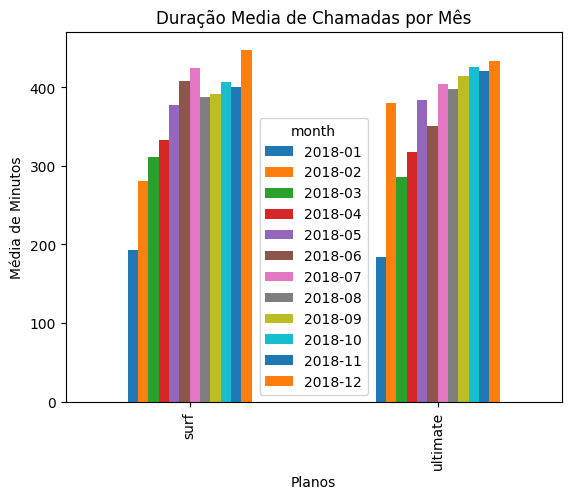

In [384]:
#Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.

duracao_media_chamadas = pd.pivot_table(dados_complet, values='calls_duration_month',index='plan',columns='month',aggfunc='mean').plot(
    kind='bar', 
    title='Duração Media de Chamadas por Mês',
    xlabel='Planos',
    ylabel='Média de Minutos')



<div class="alert alert-warning">
<strong>Comentário do revisor v1</strong>

Acredito que colocar os planos lado a lado como no exemplo abaixo ajudaria bastante na compreensão dos comportamentos. O que acha?

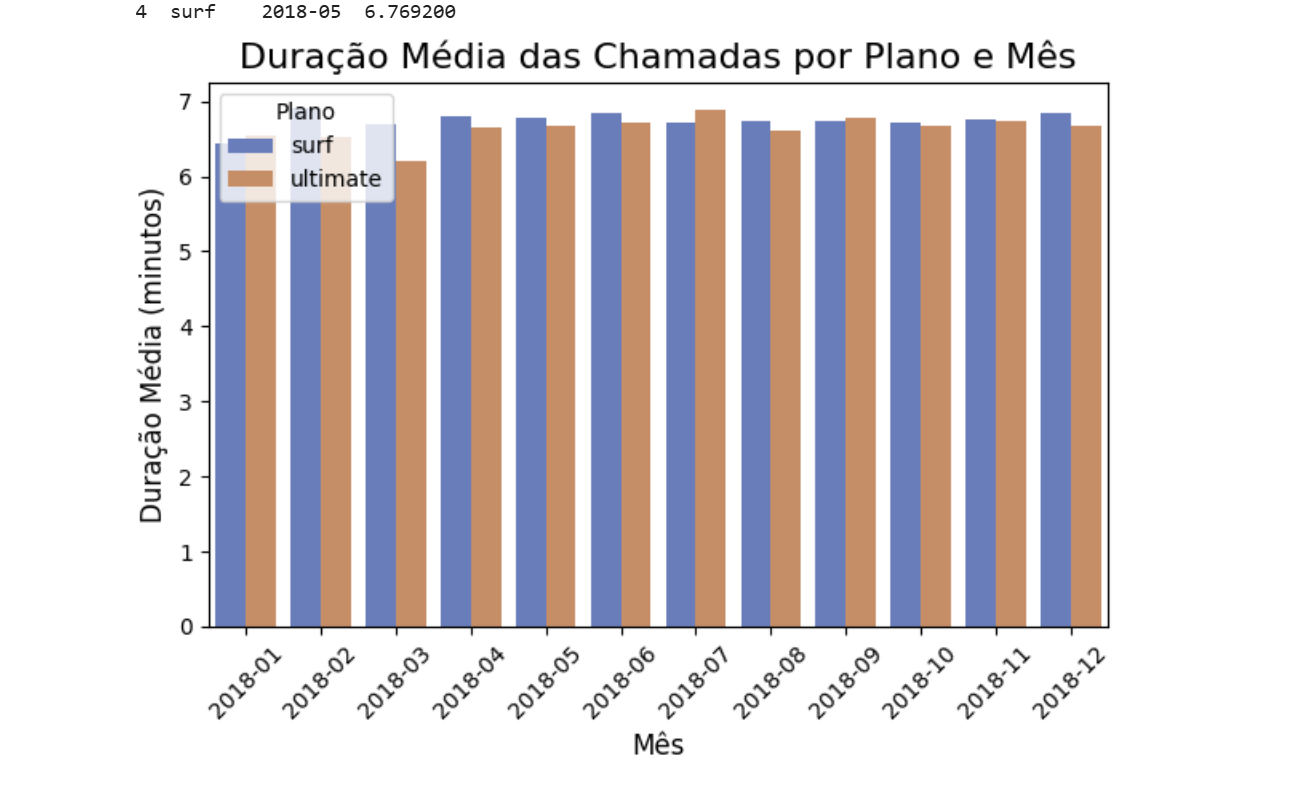
</div>


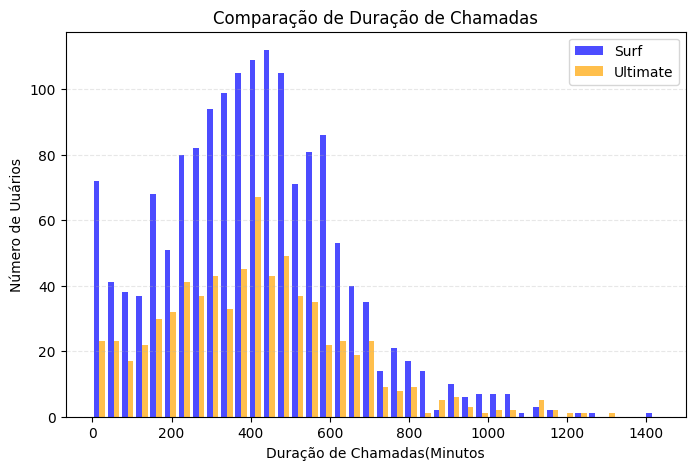

,user_id,month,month_calls,calls_duration_month,monthly_messages,mb_monthly,plan,city,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included,gb_monthly,receita_mensal
0,1000,2018-12,16.0,117.0,11.0,1901.47,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,30,2,70.00
1,1001,2018-08,27.0,172.0,30.0,6919.15,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20.0,10.0,0.03,0.03,surf,15,7,20.00
2,1001,2018-09,49.0,298.0,44.0,13314.82,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20.0,10.0,0.03,0.03,surf,15,14,20.00
3,1001,2018-10,65.0,375.0,53.0,22330.49,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20.0,10.0,0.03,0.03,surf,15,22,90.09
4,1001,2018-11,64.0,405.0,36.0,18504.30,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20.0,10.0,0.03,0.03,surf,15,19,60.00


In [385]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.
surf_minutos = dados_complet[dados_complet['plan'] == 'surf']['calls_duration_month']
ultimate_minutos = dados_complet[dados_complet['plan'] == 'ultimate']['calls_duration_month']

plt.figure(figsize=(8,5))
plt.hist([surf_minutos, ultimate_minutos], 
         bins=40,
         alpha=0.7,
         label=['Surf', 'Ultimate'], 
         color=['blue', 'orange'], )
plt.title("Comparação de Duração de Chamadas")
plt.xlabel("Duração de Chamadas(Minutos")
plt.ylabel("Número de Uuários")
plt.legend()
plt.grid(axis='y',linestyle='--',alpha=0.3)
plt.show()

dados_complet.head()

.

In [386]:
# Calcule a média e a variância da duração mensal das chamadas
#Médias de cada plano
surf_mean = surf_minutos.mean()
ultimate_mean = ultimate_minutos.mean()

#Variância de cada plano.
surf_variancia = np.var(surf_minutos)
ultimate_variancia = np.var(ultimate_minutos)


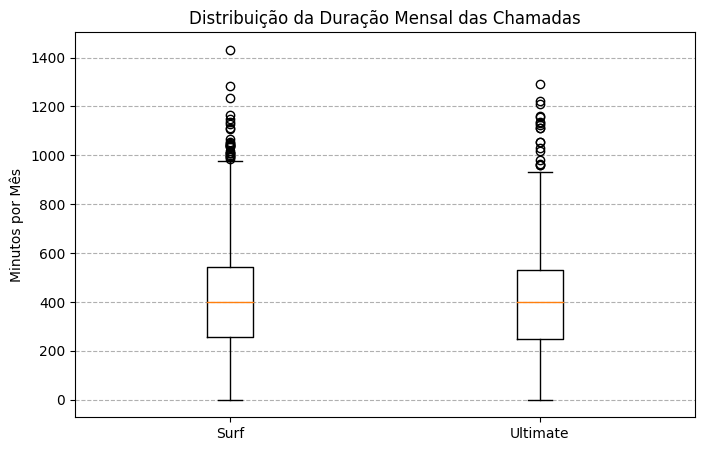

In [387]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas

plt.figure(figsize=(8,5))
plt.boxplot([surf_minutos,ultimate_minutos],labels=['Surf','Ultimate'])
plt.title("Distribuição da Duração Mensal das Chamadas")
plt.ylabel("Minutos por Mês")
plt.grid(axis='y',linestyle='--')
plt.show()



Podemos perceber que a mediana de ambos os planos são bem parecidas, o que quer dizer que independente do plano os clientes tem uma consumo parecido de quantidade de duração de chamadas, o que acaba gerando um preço adicional para as pessoas que tem o plano 'surf'.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

As visualizações (considerando o ajuste) e conclusões fornecidas no estudo das chamadas estão coerentes com o esperado para essa sessão.
</div>


### Mensagens

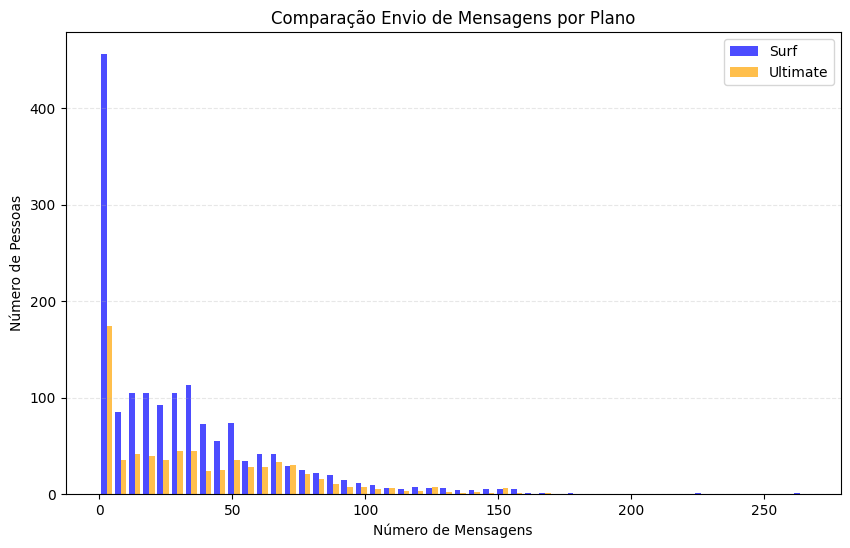

In [388]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês

surf_mensagens = dados_complet[dados_complet['plan']=='surf']['monthly_messages']
ultimate_mensagens = dados_complet[dados_complet['plan']=='ultimate']['monthly_messages']

plt.figure(figsize=(10, 6))
plt.hist([surf_mensagens,ultimate_mensagens], 
         bins=50,
         alpha=0.7,
         color=['blue','orange'], 
         label=['Surf','Ultimate'])

plt.title("Comparação Envio de Mensagens por Plano")
plt.xlabel("Número de Mensagens")
plt.ylabel("Número de Pessoas")
plt.grid(axis='y',linestyle='--',alpha=0.3)
plt.legend()
plt.show()


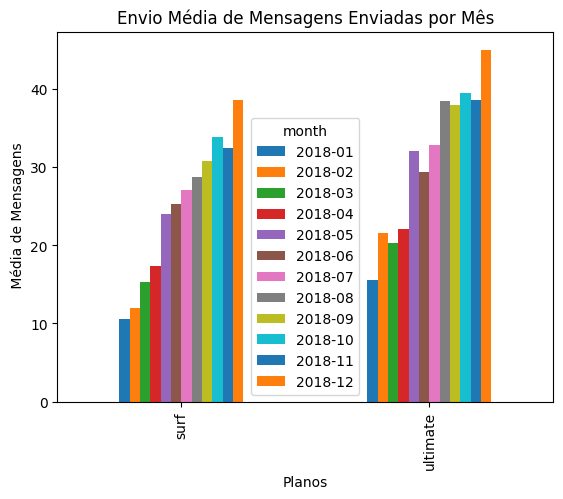

In [389]:
#Compare a média de envio de mensagens de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.
envio_medio_mensagens= pd.pivot_table(dados_complet, values='monthly_messages',index='plan',columns='month',aggfunc='mean').plot(
    kind='bar',
    title='Envio Média de Mensagens Enviadas por Mês',
    xlabel='Planos',
    ylabel=' Média de Mensagens')

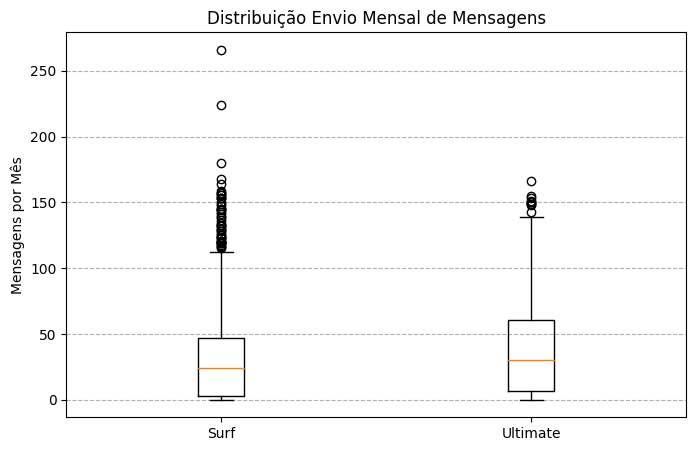

In [390]:
#Diagrama de caixa para visualizar a distribuição do envio mensal das mensagens.

plt.figure(figsize=(8,5))
plt.boxplot([surf_mensagens,ultimate_mensagens],labels=['Surf','Ultimate'])
plt.title("Distribuição Envio Mensal de Mensagens")
plt.ylabel("Mensagens por Mês")
plt.grid(axis='y',linestyle='--')
plt.show()

Podemos notar que por mais que as mediana esteja parecidas, o plano ultimate tem uma grande concentracao dos seus cliente dentro do plano sem exeder o limite, ja o plano surf temos muito cliente que exedem o limite do plano e pagam a mais todos os meses. 

### Internet

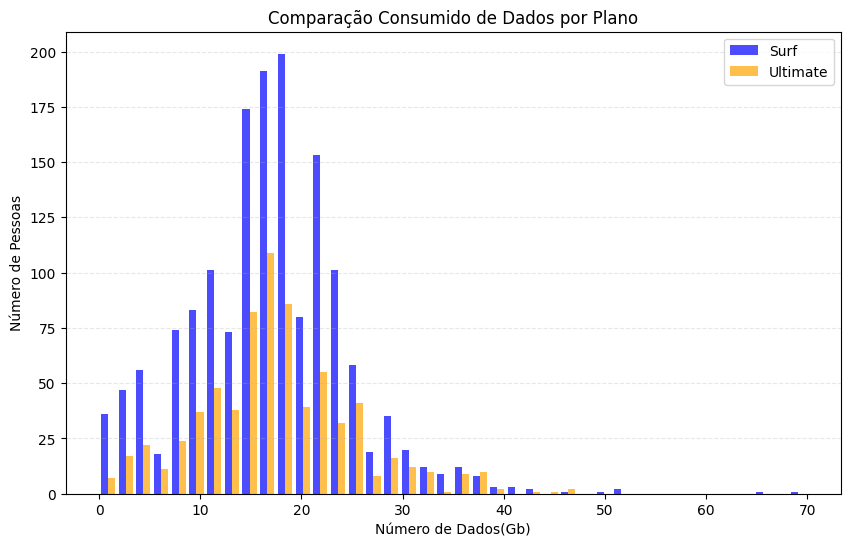

In [391]:
# Comparei a quantidade de tráfego de internet consumido pelos usuários por plano.
surf_dados= dados_complet[dados_complet['plan']=='surf']['gb_monthly']
ultimate_dados = dados_complet[dados_complet['plan']=='ultimate']['gb_monthly']

plt.figure(figsize=(10, 6))
plt.hist([surf_dados,ultimate_dados], 
         bins=40,
         alpha=0.7,
         color=['blue','orange'], 
         label=['Surf','Ultimate'])

plt.title("Comparação Consumido de Dados por Plano")
plt.xlabel("Número de Dados(Gb)")
plt.ylabel("Número de Pessoas")
plt.grid(axis='y',linestyle='--',alpha=0.3)
plt.legend()
plt.show()



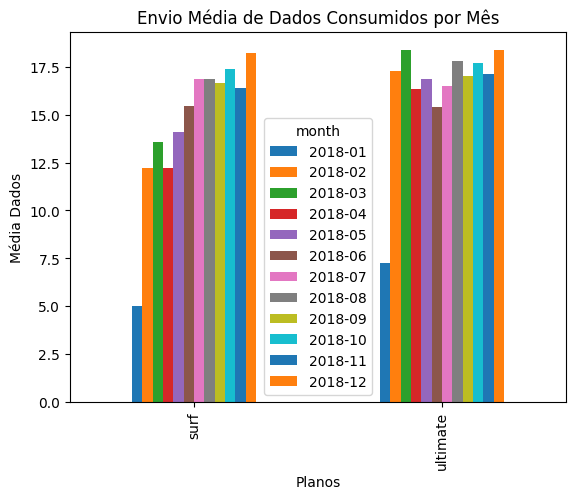

In [392]:
#Comparei a média de consumo de daos de cada plano para cada mês. Criei um gráfico de barras para visualizar o resultado.
media_dados = pd.pivot_table(dados_complet, values='gb_monthly',index='plan',columns='month',aggfunc='mean').plot(
    kind='bar',
    title='Envio Média de Dados Consumidos por Mês',
    xlabel='Planos',
    ylabel='Média Dados')

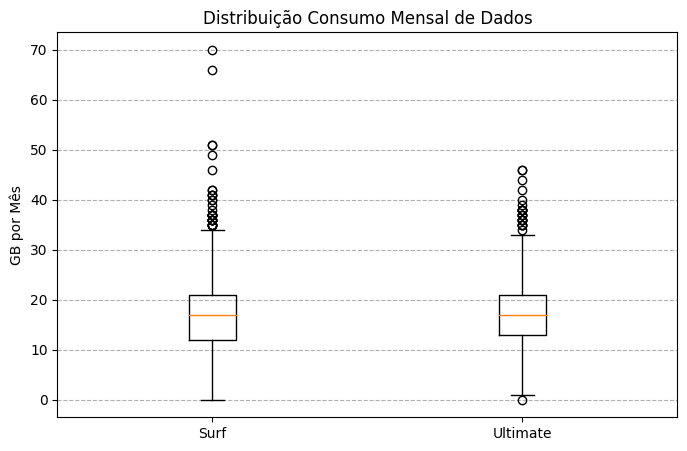

In [393]:

#Diagrama de caixa para visualizar a distribuição do consumo mensal de dados.
plt.figure(figsize=(8,5))
plt.boxplot([surf_dados,ultimate_dados],labels=['Surf','Ultimate'])
plt.title("Distribuição Consumo Mensal de Dados")
plt.ylabel("GB por Mês")
plt.grid(axis='y',linestyle='--')
plt.show()


Podemos observar que mesmo a mediana se mantendo muito parecida, tenho informações diferentes em cada plano. No plano surf grande parte das pessoas excedem o consumo de dados já no plano ultimate pouquíssimas pessoas excedem o plano na parte de volume de dados consumidos.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Mensagens e internet tiveram o seu comportamento investigado conforme solicitado na lição, com gráficos e conclusão apresentados.
</div>


## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

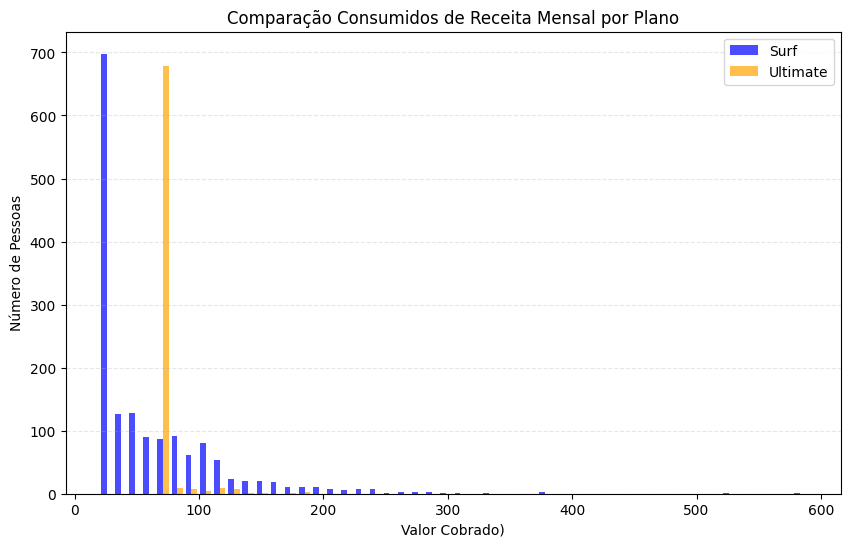

In [394]:
# Comparei a quantidade de tráfego de internet consumido pelos usuários por plano.
surf_receita_mensal= dados_complet[dados_complet['plan']=='surf']['receita_mensal']
ultimate_receita_mensal = dados_complet[dados_complet['plan']=='ultimate']['receita_mensal']

plt.figure(figsize=(10, 6))
plt.hist([surf_receita_mensal,ultimate_receita_mensal], 
         bins=50,
         alpha=0.7,
         color=['blue','orange'], 
         label=['Surf','Ultimate'])

plt.title("Comparação Consumidos de Receita Mensal por Plano")
plt.xlabel("Valor Cobrado)")
plt.ylabel("Número de Pessoas")
plt.grid(axis='y',linestyle='--',alpha=0.3)
plt.legend()
plt.show()


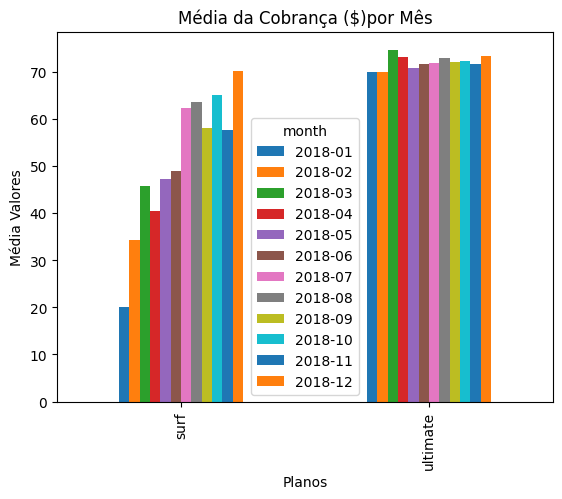

In [395]:
#Comparei a média de consumo de daos de cada plano para cada mês. Criei um gráfico de barras para visualizar o resultado.
media_receita_mensal = pd.pivot_table(dados_complet, values='receita_mensal',index='plan',columns='month',aggfunc='mean').plot(
    kind='bar',
    title='Média da Cobrança ($)por Mês',
    xlabel='Planos',
    ylabel='Média Valores')


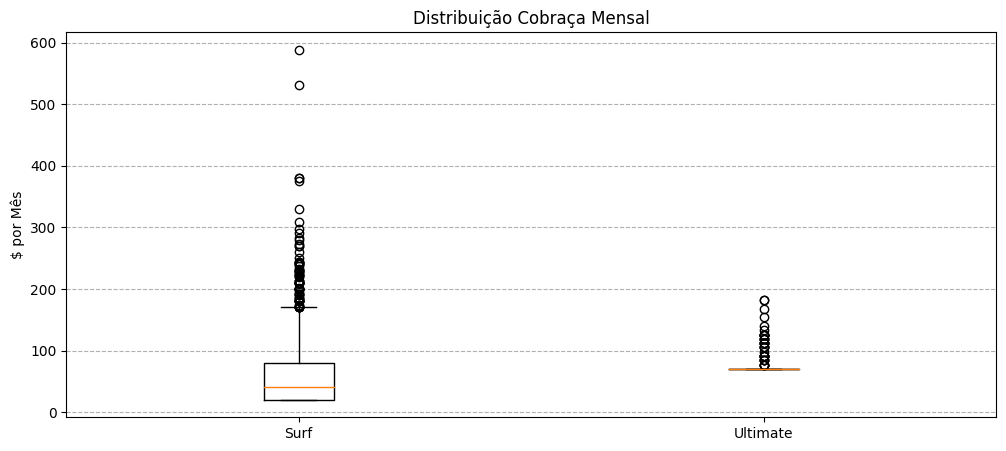

In [396]:
#Diagrama de caixa para visualizar a distribuição do consumo mensal de dados.
plt.figure(figsize=(12,5))
plt.boxplot([surf_receita_mensal,ultimate_receita_mensal],labels=['Surf','Ultimate'])
plt.title("Distribuição Cobraça Mensal")
plt.ylabel("$ por Mês")
plt.grid(axis='y',linestyle='--')
plt.show()


Isso está ocorrendo porque os clientes dos plano surf usam muito mais do que os limites  plano que eles contrataram o que gera cobranças muito maiores para eles do que para os clientes do plano ultimate. Os clientes surf pagam consideravelmente mais porque tem um plano com limites inferiores e consomem tanto quanto os clientes do plano ultimate.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Receita foi investigada por meio de gráficos e conclusões adequadas.

</div>


## Teste hipóteses estatísticas

.

Baseado nos planos, queremos observar se a receita dos planos Ultimate e Surf tem a receita média parecidas.
H₀: A receita média dos usuarios do plano Ultimate é igual a receita média dos usuarios do plano Surf.
H₁: A receita média dos usuários do plano Ultimate é diferente da receita média dos usuários do plano Surf.


In [397]:
# Teste as hipóteses

alpha = 0.01
results_receita_mensal = st.ttest_ind(surf_receita_mensal,ultimate_receita_mensal, equal_var=False)
print('valor-p:',results_receita_mensal.pvalue)

if (results_receita_mensal.pvalue < alpha):
    print("Rejeitamos a hipótese Nula")
else:
    print("Não Podemos Rejeitar a hipótese Nula")

valor-p: 3.6278039040985444e-16
Rejeitamos a hipótese Nula


.

Baseado nos planos , queremos observar se a receita dos planos dos usuários da área NY-NJ e os usuários das demais regiões tem as receitas média parecidas. H₀: A receita média usuários da região NY-NJ é igual a receita média dos usuários das demais regiões. H₁: A receita média usuários da região NY-NJ é diferente da receita média dos usuários das demais regiões.

In [398]:
# Teste as hipóteses
# Função para categorizar as cidades em regiões
def categorizar_regiao(city):
    if 'NY' in city or 'NJ' in city:
        return 'NY-NJ'
    else:
        return 'Outras'

# Aplicar a categorização
dados_complet['regiao'] = dados_complet['city'].apply(categorizar_regiao)

# Filtrar os dados diretamente (mais simples!)
ny_nj_receitas = dados_complet[dados_complet['regiao'] == 'NY-NJ']['receita_mensal']
outras_receitas = dados_complet[dados_complet['regiao'] == 'Outras']['receita_mensal']

alpha=0.01

results_regiao_receita = st.ttest_ind(ny_nj_receitas,outras_receitas)
print('valor-p:',results_regiao_receita.pvalue)

if (results_regiao_receita.pvalue < alpha):
    print("Rejeitamos a hipótese Nula")
else:
    print("Não Podemos Rejeitar a hipótese Nula")


valor-p: 0.10771811100928358
Não Podemos Rejeitar a hipótese Nula




<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Os testes foram formulados, implementados e analisados corretamente. Muito bom!
</div>

## Conclusão geral



In [399]:
# Médias de consumo por plano
print("=== MÉDIAS DE CONSUMO ===")
print(f"Duração média chamadas Surf: {surf_minutos.mean():.2f} minutos")
print(f"Duração média chamadas Ultimate: {ultimate_minutos.mean():.2f} minutos")

print(f"Mensagens médias Surf: {surf_mensagens.mean():.2f}")
print(f"Mensagens médias Ultimate: {ultimate_mensagens.mean():.2f}")

print(f"Dados médios Surf: {surf_dados.mean():.2f} GB")
print(f"Dados médios Ultimate: {ultimate_dados.mean():.2f} GB")

print(f"Receita média Surf: ${surf_receita_mensal.mean():.2f}")
print(f"Receita média Ultimate: ${ultimate_receita_mensal.mean():.2f}")

=== MÉDIAS DE CONSUMO ===
Duração média chamadas Surf: 405.25 minutos
Duração média chamadas Ultimate: 406.71 minutos
Mensagens médias Surf: 31.16
Mensagens médias Ultimate: 37.55
Dados médios Surf: 16.67 GB
Dados médios Ultimate: 17.31 GB
Receita média Surf: $60.33
Receita média Ultimate: $72.31


Aos longo do projeto pudemos analisar alguns comportamento tanto dos usuários do plano 'Surf' quanto do plano 'Ultimate'. O plano mais contrato é o surf com 333 usuários em um total de 500. Depois de analisar os gráficos notamos que os números de consumos de ambos são bem parecidos, o que modificar o valor mensal que muitos usuários do plano Surf pagam, visto que o consumo deles são parecidos, mas dentro dos limites do plano Ultimate o que gera sempre um valor excedente. Mesmo sendo o plano menos contrato pelo usuários e não tendo muitos valores excedentes pelos usuários. Recomendo que a empresa foque em propaganda para o plano Ultimate.